# LIMFADD: Account Classification and Clustering

This notebook classifies Instagram accounts into **Bot, Real, Scam, and Spam** and then explores whether the same feature space naturally forms clusters.


1. Load and inspect the data
2. Clean missing/bad values and encode categorical columns
3. Remove extreme numeric outliers
4. Split the data into train/test sets
5. Compare four supervised models
6. Select useful features and compare performance
7. Build voting and stacking ensembles
8. Tune the base models with GridSearchCV
9. Compare models with accuracy and ROC-AUC
10. Run PCA + KMeans/Agglomerative clustering




## 1. Setup & data

In [4]:
%pip install pandas matplotlib seaborn scikit-learn scipy umap-learn xgboost


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import umap.umap_ as umap
from xgboost import XGBClassifier

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, VotingClassifier
from sklearn.feature_selection import RFE, SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import (
    accuracy_score,
    adjusted_rand_score,
    auc,
    calinski_harabasz_score,
    classification_report,
    confusion_matrix,
    davies_bouldin_score,
    roc_auc_score,
    roc_curve,
    silhouette_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, cross_validate, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer

warnings.filterwarnings('ignore')

SEED = 42
numeric_cols = [
    'Followers', 'Following', 'Following/Followers',
    'Posts', 'Posts/Followers', 'Mutual Friends'
]
binary_cols = ['Bio', 'Profile Picture', 'External Link', 'Threads']

auto_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)


c:\Users\kokan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
df = pd.read_csv('Dataset/LIMFADD.csv')

print('Dataset shape:', df.shape)
print('Columns:', df.columns.tolist())
print('\nFirst 5 rows:')
display(df.head())


Dataset shape: (15000, 11)
Columns: ['Followers', 'Following', 'Following/Followers', 'Posts', 'Posts/Followers', 'Bio', 'Profile Picture', 'External Link', 'Mutual Friends', 'Threads', 'Labels']

First 5 rows:


,Followers,Following,Following/Followers,Posts,Posts/Followers,Bio,Profile Picture,External Link,Mutual Friends,Threads,Labels
0,2,2757,1378.5,0,0,N,N,N,0,N,Bot
1,2,505,252.5,0,0,N,Yes,N,0,N,Scam
2,6786,1782,0.262599469,1589,6051.040404,yes,N,Yes,10,N,Real
3,21,1281,61,0,0,N,Yes,N,0,N,Bot
4,585,1682,2.875213675,2663,926.1920333,yes,N,N,12,Yes,Real


## 2. Preprocessing

In [4]:
df_clean = df.copy()

# Some ratio values are stored as strings such as '#DIV/0!'. Turn them into NaN first.
for col in ['Following/Followers', 'Posts/Followers']:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Fill missing numeric values with the column mean.
num_imputer = SimpleImputer(strategy='mean')
df_clean[numeric_cols] = num_imputer.fit_transform(df_clean[numeric_cols])

# These categorical columns are binary in this dataset, so label encoding is enough.
for col in binary_cols:
    mode = df_clean[col].mode()
    fill_value = mode.iloc[0] if not mode.empty else 'N'
    df_clean[col] = df_clean[col].fillna(fill_value)
    df_clean[col] = LabelEncoder().fit_transform(df_clean[col])

# Convert the target labels to integers for scikit-learn.
target_encoder = LabelEncoder()
df_clean['Labels_encoded'] = target_encoder.fit_transform(df_clean['Labels'])
class_names = target_encoder.classes_

print('Missing values left:', int(df_clean.isna().sum().sum()))
print('Classes:', list(class_names))


Missing values left: 0
Classes: ['Bot', 'Real', 'Scam', 'Spam']


           Followers     Following  Following/Followers         Posts  \
count   15000.000000  15000.000000         15000.000000  15000.000000   
mean    23397.378933   1385.350000           112.144204    427.830200   
std     41920.419061   1600.823163           341.740687    678.889037   
min         0.000000      0.000000             0.000000      0.000000   
25%         6.000000    369.000000             0.026129      1.000000   
50%        48.000000    725.500000             3.691260      4.000000   
75%     19535.250000   1747.000000           112.144204    578.250000   
max    163000.000000   6692.000000          6644.000000   2669.000000   

       Posts/Followers           Bio  Profile Picture  External Link  \
count     1.500000e+04  15000.000000     15000.000000    15000.00000   
mean      6.696048e+04      0.510133         0.496933        0.25220   
std       6.328497e+05      0.649763         0.500007        0.43429   
min       0.000000e+00      0.000000         0.000000 

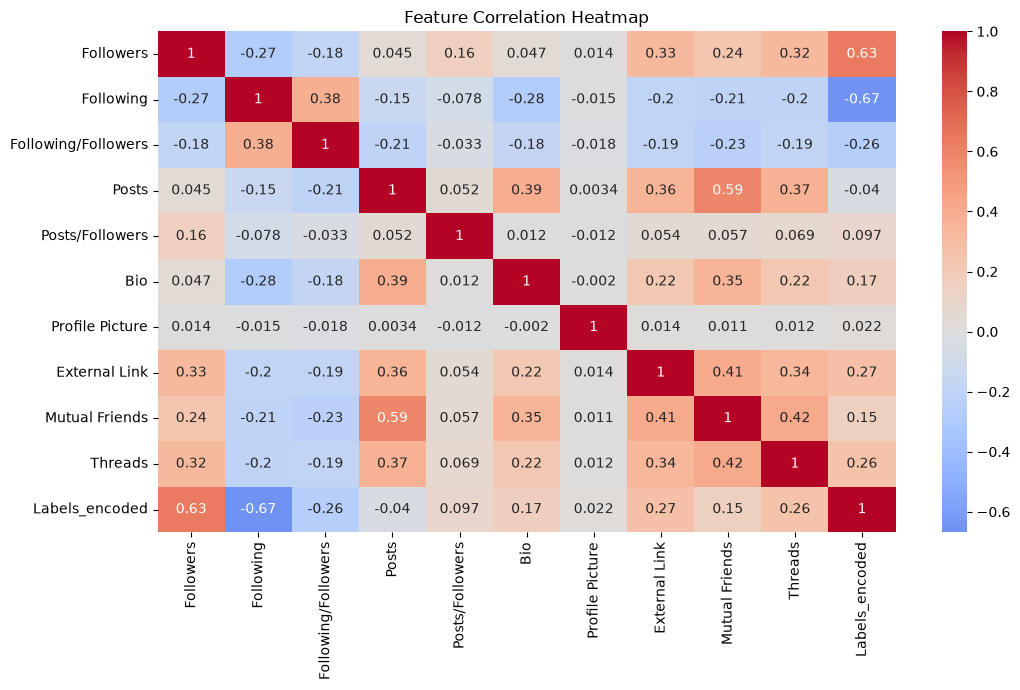

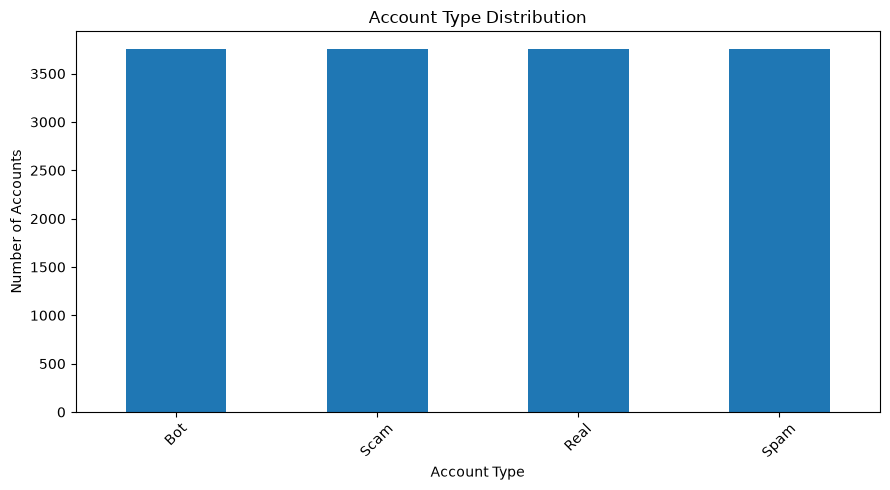

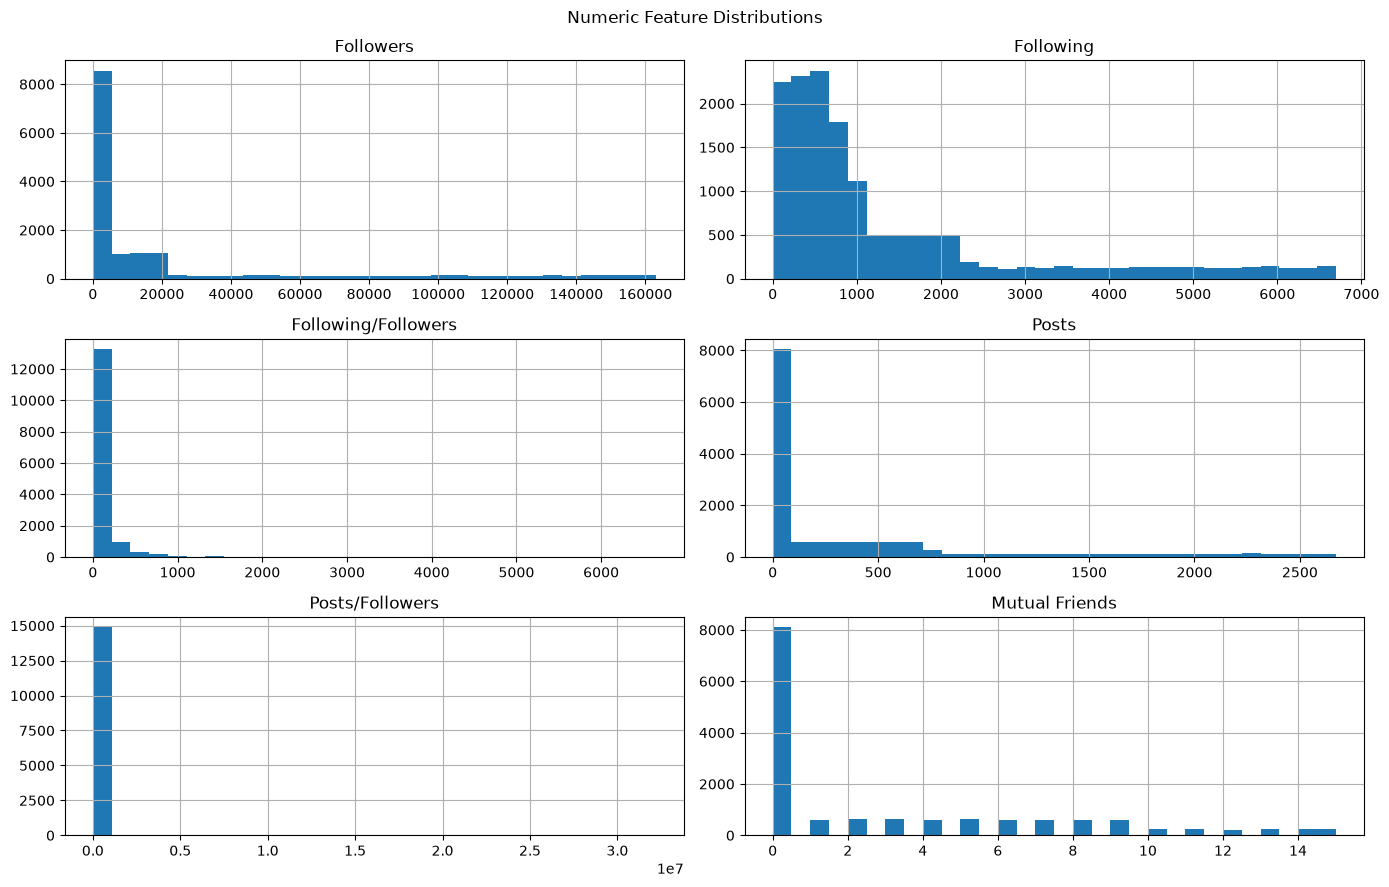

In [5]:
print(df_clean.describe())

plt.figure(figsize=(11, 7))
sns.heatmap(
    df_clean.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm',
    center=0
)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
df_clean['Labels'].value_counts().plot(kind='bar')
plt.title('Account Type Distribution')
plt.xlabel('Account Type')
plt.ylabel('Number of Accounts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

df_clean[numeric_cols].hist(bins=30, figsize=(14, 9))
plt.suptitle('Numeric Feature Distributions')
plt.tight_layout()
plt.show()


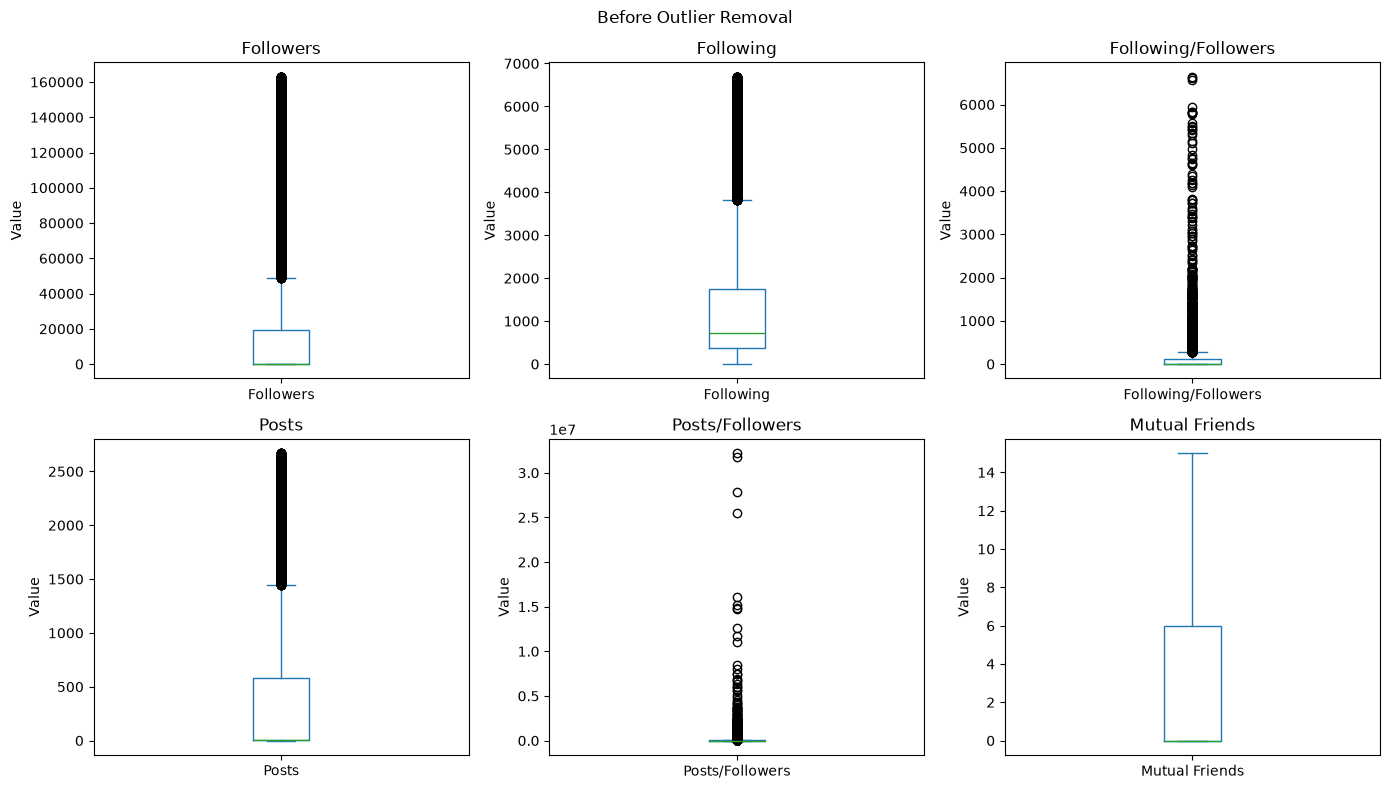

Rows before: 15000
Outliers removed: 1168
Rows after: 13832


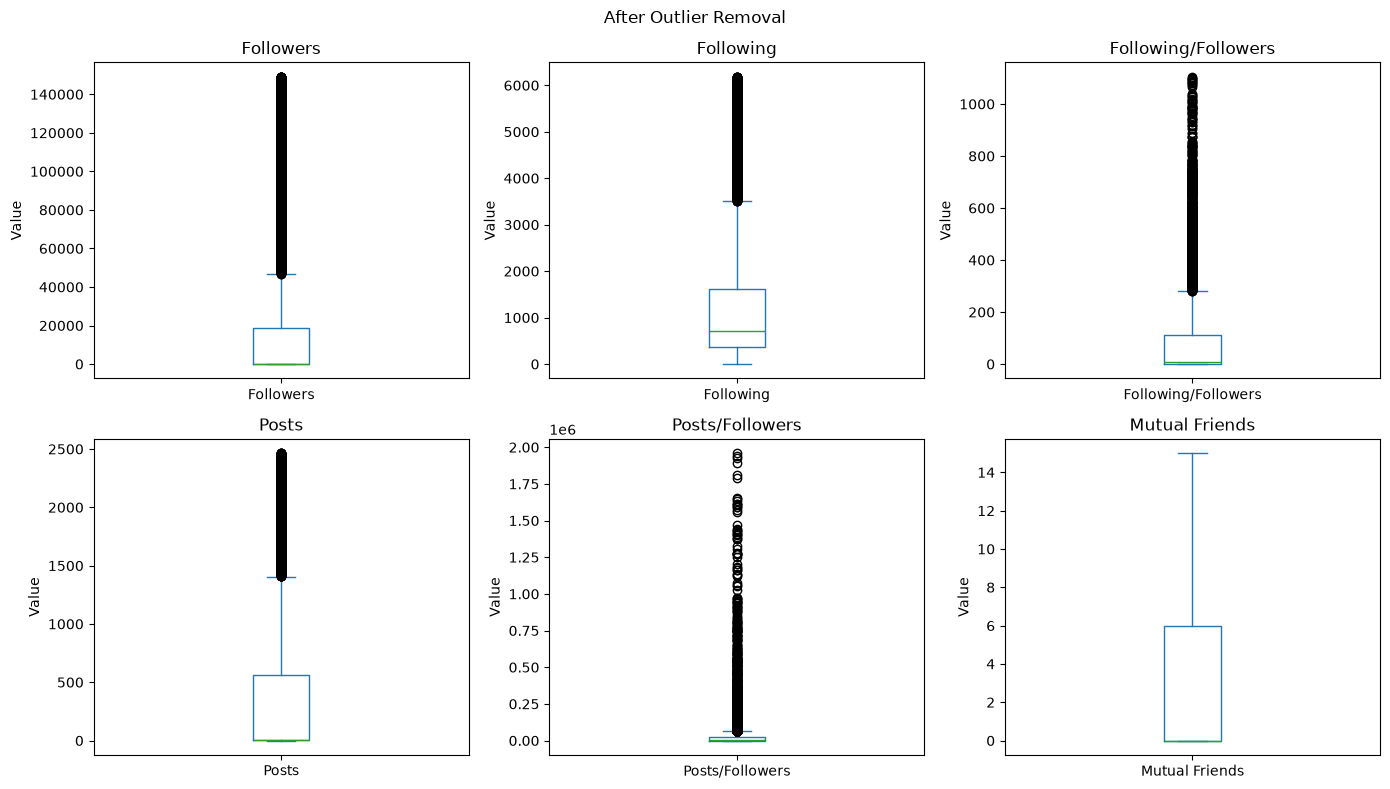

In [6]:
def show_boxplots(data, columns, title):
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    for ax, col in zip(axes.ravel(), columns):
        data[col].plot(kind='box', ax=ax)
        ax.set_title(col)
        ax.set_ylabel('Value')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_boxplots(df_clean, numeric_cols, 'Before Outlier Removal')

# Treat observations with |z-score| >= 3 on any numeric feature as outliers.
z = np.abs(stats.zscore(df_clean[numeric_cols]))
keep_rows = (z < 3).all(axis=1)

print('Rows before:', len(df_clean))
print('Outliers removed:', int((~keep_rows).sum()))

df_clean = df_clean.loc[keep_rows].copy()

print('Rows after:', len(df_clean))
show_boxplots(df_clean, numeric_cols, 'After Outlier Removal')


In [7]:
X = df_clean.drop(columns=['Labels', 'Labels_encoded'])
y = df_clean['Labels_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('\nTraining class counts:')
print(y_train.value_counts().sort_index())


Train shape: (11065, 10)
Test shape: (2767, 10)

Training class counts:
Labels_encoded
0    2621
1    2756
2    3000
3    2688
Name: count, dtype: int64


## 3. Helpers

In [8]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)


def make_base_models():
    # Scaling is inside the LR/SVM pipelines so every CV fold learns its own scaler.
    return {
        'Logistic Regression': make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=1000, random_state=SEED)
        ),
        'SVM': make_pipeline(
            StandardScaler(),
            SVC(probability=True, random_state=SEED)
        ),
        'Random Forest': RandomForestClassifier(random_state=SEED),
        'XGBoost': XGBClassifier(random_state=SEED, eval_metric='mlogloss'),
    }


def make_ensembles(base_models, suffix=''):
    estimators = [
        ('lr', base_models['Logistic Regression']),
        ('svm', base_models['SVM']),
        ('rf', base_models['Random Forest']),
        ('xgb', base_models['XGBoost']),
    ]

    return {
        f'Hard Voting{suffix}': VotingClassifier(estimators=estimators, voting='hard'),
        f'Soft Voting{suffix}': VotingClassifier(estimators=estimators, voting='soft'),
        f'Stacking{suffix}': StackingClassifier(
            estimators=estimators,
            final_estimator=LogisticRegression(max_iter=1000),
            cv=5
        ),
    }


def evaluate_models(models, X_tr, X_te, y_tr, y_te, feature_set, cv=cv5):
    """Fit models and evaluate them on the held-out test set and training CV."""
    results = {}

    for name, model in models.items():
        model.fit(X_tr, y_tr)

        train_pred = model.predict(X_tr)
        test_pred = model.predict(X_te)

        cv_scores = cross_val_score(
            model,
            X_tr,
            y_tr,
            cv=cv,
            scoring='accuracy'
        )

        results[name] = {
            'model': model,
            'features': feature_set,
            'X_test': X_te,
            'train_accuracy': accuracy_score(y_tr, train_pred),
            'test_accuracy': accuracy_score(y_te, test_pred),
            'cv_mean': cv_scores.mean(),
            'cv_std': cv_scores.std(),
        }

        print(
            f'{name}: '
            f'train={results[name]["train_accuracy"]:.4f}, '
            f'test={results[name]["test_accuracy"]:.4f}, '
            f'CV={results[name]["cv_mean"]:.4f} '
            f'+/- {results[name]["cv_std"] * 2:.4f}'
        )

    return results


def show_model_report(name, model, X_te, y_te):
    predictions = model.predict(X_te)

    plt.figure(figsize=(7, 5))
    sns.heatmap(
        confusion_matrix(y_te, predictions),
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    print(classification_report(y_te, predictions, target_names=class_names))


def print_cv_metrics(name, model, X_train_data, y_train_data, cv):
    scores = cross_validate(
        model,
        X_train_data,
        y_train_data,
        cv=cv,
        scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
    )

    print(f'\n{name} - {cv.get_n_splits()}-fold CV')
    for metric in ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']:
        values = scores[f'test_{metric}']
        print(f'{metric}: {values.mean():.4f} +/- {values.std() * 2:.4f}')


## 4. Base models

In [9]:
print('Base model results - all features')
results_full = evaluate_models(
    make_base_models(),
    X_train,
    X_test,
    y_train,
    y_test,
    feature_set='full'
)


Base model results - all features
Logistic Regression: train=0.9469, test=0.9505, CV=0.9469 +/- 0.0084
SVM: train=0.9676, test=0.9696, CV=0.9631 +/- 0.0108
Random Forest: train=1.0000, test=0.9805, CV=0.9789 +/- 0.0049
XGBoost: train=0.9996, test=0.9783, CV=0.9763 +/- 0.0043


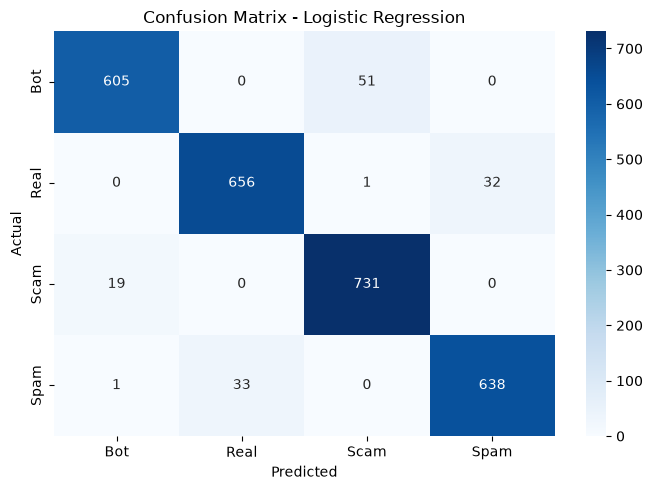

              precision    recall  f1-score   support

         Bot       0.97      0.92      0.94       656
        Real       0.95      0.95      0.95       689
        Scam       0.93      0.97      0.95       750
        Spam       0.95      0.95      0.95       672

    accuracy                           0.95      2767
   macro avg       0.95      0.95      0.95      2767
weighted avg       0.95      0.95      0.95      2767



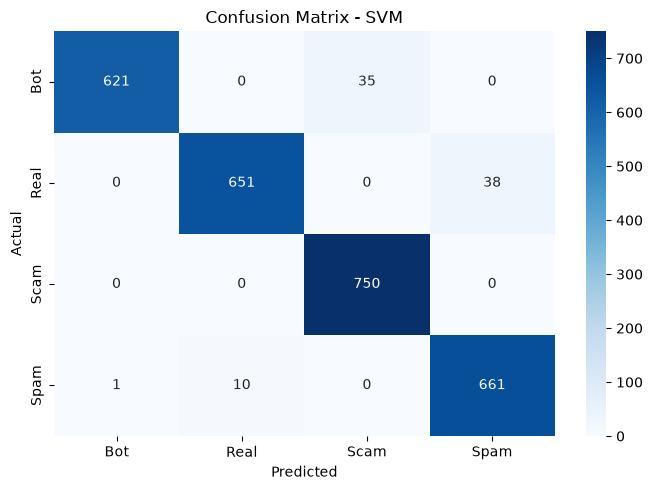

              precision    recall  f1-score   support

         Bot       1.00      0.95      0.97       656
        Real       0.98      0.94      0.96       689
        Scam       0.96      1.00      0.98       750
        Spam       0.95      0.98      0.96       672

    accuracy                           0.97      2767
   macro avg       0.97      0.97      0.97      2767
weighted avg       0.97      0.97      0.97      2767


Logistic Regression - 5-fold CV
accuracy: 0.9469 +/- 0.0084
precision_macro: 0.9482 +/- 0.0079
recall_macro: 0.9457 +/- 0.0088
f1_macro: 0.9466 +/- 0.0086

SVM - 10-fold CV
accuracy: 0.9640 +/- 0.0119
precision_macro: 0.9660 +/- 0.0109
recall_macro: 0.9629 +/- 0.0122
f1_macro: 0.9638 +/- 0.0120


In [10]:
logreg = results_full['Logistic Regression']['model']
svm_model = results_full['SVM']['model']

show_model_report('Logistic Regression', logreg, X_test, y_test)
show_model_report('SVM', svm_model, X_test, y_test)

print_cv_metrics('Logistic Regression', logreg, X_train, y_train, cv5)
print_cv_metrics('SVM', svm_model, X_train, y_train, cv10)


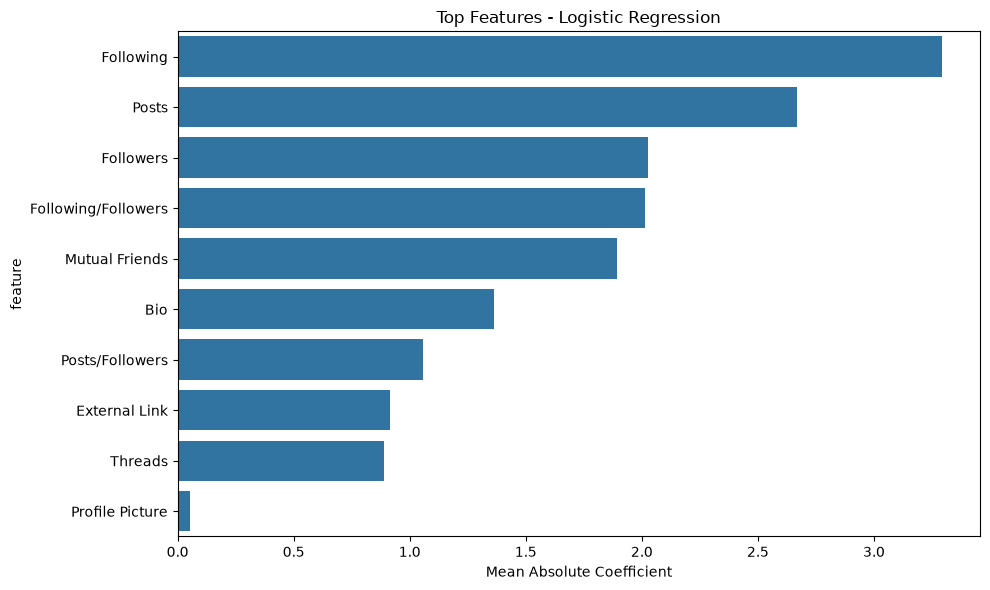

In [11]:
# For logistic regression, larger absolute coefficients mean stronger influence on the decision.
logreg_estimator = logreg.named_steps['logisticregression']

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': np.abs(logreg_estimator.coef_).mean(axis=0)
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x='importance', y='feature')
plt.title('Top Features - Logistic Regression')
plt.xlabel('Mean Absolute Coefficient')
plt.tight_layout()
plt.show()


## 5. Feature selection

In [12]:
# Select the five features with the strongest ANOVA F-scores.
selector = SelectKBest(score_func=f_classif, k=5)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)
selected_features = X.columns[selector.get_support()].tolist()

feature_scores = pd.DataFrame({
    'feature': X.columns,
    'f_score': selector.scores_,
    'p_value': selector.pvalues_
}).sort_values('f_score', ascending=False)

display(feature_scores)
print('Selected features:', selected_features)

# RFE is shown as a second feature-selection method.
rfe = RFE(
    LogisticRegression(max_iter=1000, random_state=SEED),
    n_features_to_select=5
)

# RFE needs a numeric matrix, so scale only the training data used for this comparison.
X_train_scaled = StandardScaler().fit_transform(X_train)
rfe.fit(X_train_scaled, y_train)
print('RFE-selected features:', X.columns[rfe.get_support()].tolist())


,feature,f_score,p_value
0,Followers,7514.594984,0.000000e+00
3,Posts,6969.408024,0.000000e+00
8,Mutual Friends,5189.129238,0.000000e+00
1,Following,5146.694492,0.000000e+00
9,Threads,1894.379150,0.000000e+00
7,External Link,1891.788492,0.000000e+00
2,Following/Followers,1738.801451,0.000000e+00
5,Bio,1609.960062,0.000000e+00
4,Posts/Followers,487.828091,1.004625e-297
6,Profile Picture,2.096533,9.840481e-02


Selected features: ['Followers', 'Following', 'Posts', 'Mutual Friends', 'Threads']
RFE-selected features: ['Followers', 'Following', 'Following/Followers', 'Posts', 'Mutual Friends']


In [13]:
print('Base models - selected features')
results_selected = evaluate_models(
    make_base_models(),
    X_train[selected_features],
    X_test[selected_features],
    y_train,
    y_test,
    feature_set='selected'
)

comparison = pd.DataFrame({
    'full features': {name: result['test_accuracy'] for name, result in results_full.items()},
    'selected features': {name: result['test_accuracy'] for name, result in results_selected.items()},
})
display(comparison.round(4))


Base models - selected features
Logistic Regression: train=0.9376, test=0.9371, CV=0.9371 +/- 0.0091
SVM: train=0.9432, test=0.9396, CV=0.9412 +/- 0.0109
Random Forest: train=0.9997, test=0.9686, CV=0.9699 +/- 0.0052
XGBoost: train=0.9963, test=0.9711, CV=0.9685 +/- 0.0054


,full features,selected features
Logistic Regression,0.9505,0.9371
SVM,0.9696,0.9396
Random Forest,0.9805,0.9686
XGBoost,0.9783,0.9711


## 6. Ensembles

In [14]:
print('Ensembles - full features')
ens_full = evaluate_models(
    make_ensembles(make_base_models()),
    X_train,
    X_test,
    y_train,
    y_test,
    feature_set='full'
)

print('\nEnsembles - selected features')
ens_selected = evaluate_models(
    make_ensembles(make_base_models(), ' (Selected)'),
    X_train[selected_features],
    X_test[selected_features],
    y_train,
    y_test,
    feature_set='selected'
)


Ensembles - full features
Hard Voting: train=0.9952, test=0.9798, CV=0.9759 +/- 0.0041
Soft Voting: train=0.9916, test=0.9834, CV=0.9793 +/- 0.0021
Stacking: train=0.9991, test=0.9805, CV=0.9783 +/- 0.0064

Ensembles - selected features
Hard Voting (Selected): train=0.9878, test=0.9714, CV=0.9673 +/- 0.0054
Soft Voting (Selected): train=0.9908, test=0.9714, CV=0.9685 +/- 0.0042
Stacking (Selected): train=0.9967, test=0.9700, CV=0.9695 +/- 0.0059


## 7. Hyperparameter tuning

In [15]:
# Tune the base models using only the training data.
param_grids = {
    'Logistic Regression': {
        'logisticregression__C': [0.1, 1, 10, 100],
        'logisticregression__solver': ['liblinear', 'lbfgs']
    },
    'SVM': {
        'svc__C': [0.1, 1, 10],
        'svc__gamma': ['scale', 'auto'],
        'svc__kernel': ['rbf', 'linear']
    },
    'Random Forest': {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5]
    },
    'XGBoost': {
        'n_estimators': [100, 200],
        'max_depth': [3, 6, 9],
        'learning_rate': [0.01, 0.1, 0.2]
    }
}

tuned_models = {}

for name, model in make_base_models().items():
    search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=cv5,
        scoring='accuracy',
        n_jobs=-1
    )
    search.fit(X_train, y_train)

    tuned_models[name] = {
        'model': search.best_estimator_,
        'params': search.best_params_,
        'score': search.best_score_
    }

    print(f'{name}: CV={search.best_score_:.4f}')
    print('Best parameters:', search.best_params_)


Logistic Regression: CV=0.9469
Best parameters: {'logisticregression__C': 1, 'logisticregression__solver': 'lbfgs'}
SVM: CV=0.9718
Best parameters: {'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Random Forest: CV=0.9820
Best parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
XGBoost: CV=0.9818
Best parameters: {'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 100}


In [16]:
tuned_base = {name: item['model'] for name, item in tuned_models.items()}

print('Ensembles - tuned base models')
ens_tuned = evaluate_models(
    make_ensembles(tuned_base, ' (Tuned)'),
    X_train,
    X_test,
    y_train,
    y_test,
    feature_set='full'
)


Ensembles - tuned base models
Hard Voting (Tuned): train=0.9820, test=0.9834, CV=0.9793 +/- 0.0030
Soft Voting (Tuned): train=0.9823, test=0.9812, CV=0.9792 +/- 0.0035
Stacking (Tuned): train=0.9849, test=0.9841, CV=0.9819 +/- 0.0032


## 8. Model comparison, ROC curves & summary

In [17]:
all_results = {
    **results_full,
    **results_selected,
    **ens_full,
    **ens_selected,
    **ens_tuned,
}

summary_df = pd.DataFrame([
    {
        'model': name,
        'features': result['features'],
        'train_acc': result['train_accuracy'],
        'test_acc': result['test_accuracy'],
        'cv_mean': result['cv_mean'],
        'cv_std': result['cv_std'],
    }
    for name, result in all_results.items()
]).sort_values('cv_mean', ascending=False)

display(summary_df.round(4))


,model,features,train_acc,test_acc,cv_mean,cv_std
12,Stacking (Tuned),full,0.9849,0.9841,0.9819,0.0016
5,Soft Voting,full,0.9916,0.9834,0.9793,0.0010
10,Hard Voting (Tuned),full,0.9820,0.9834,0.9793,0.0015
11,Soft Voting (Tuned),full,0.9823,0.9812,0.9792,0.0018
6,Stacking,full,0.9991,0.9805,0.9783,0.0032
4,Hard Voting,full,0.9952,0.9798,0.9759,0.0021
2,Random Forest,selected,0.9997,0.9686,0.9699,0.0026
9,Stacking (Selected),selected,0.9967,0.9700,0.9695,0.0030
8,Soft Voting (Selected),selected,0.9908,0.9714,0.9685,0.0021
3,XGBoost,selected,0.9963,0.9711,0.9685,0.0027


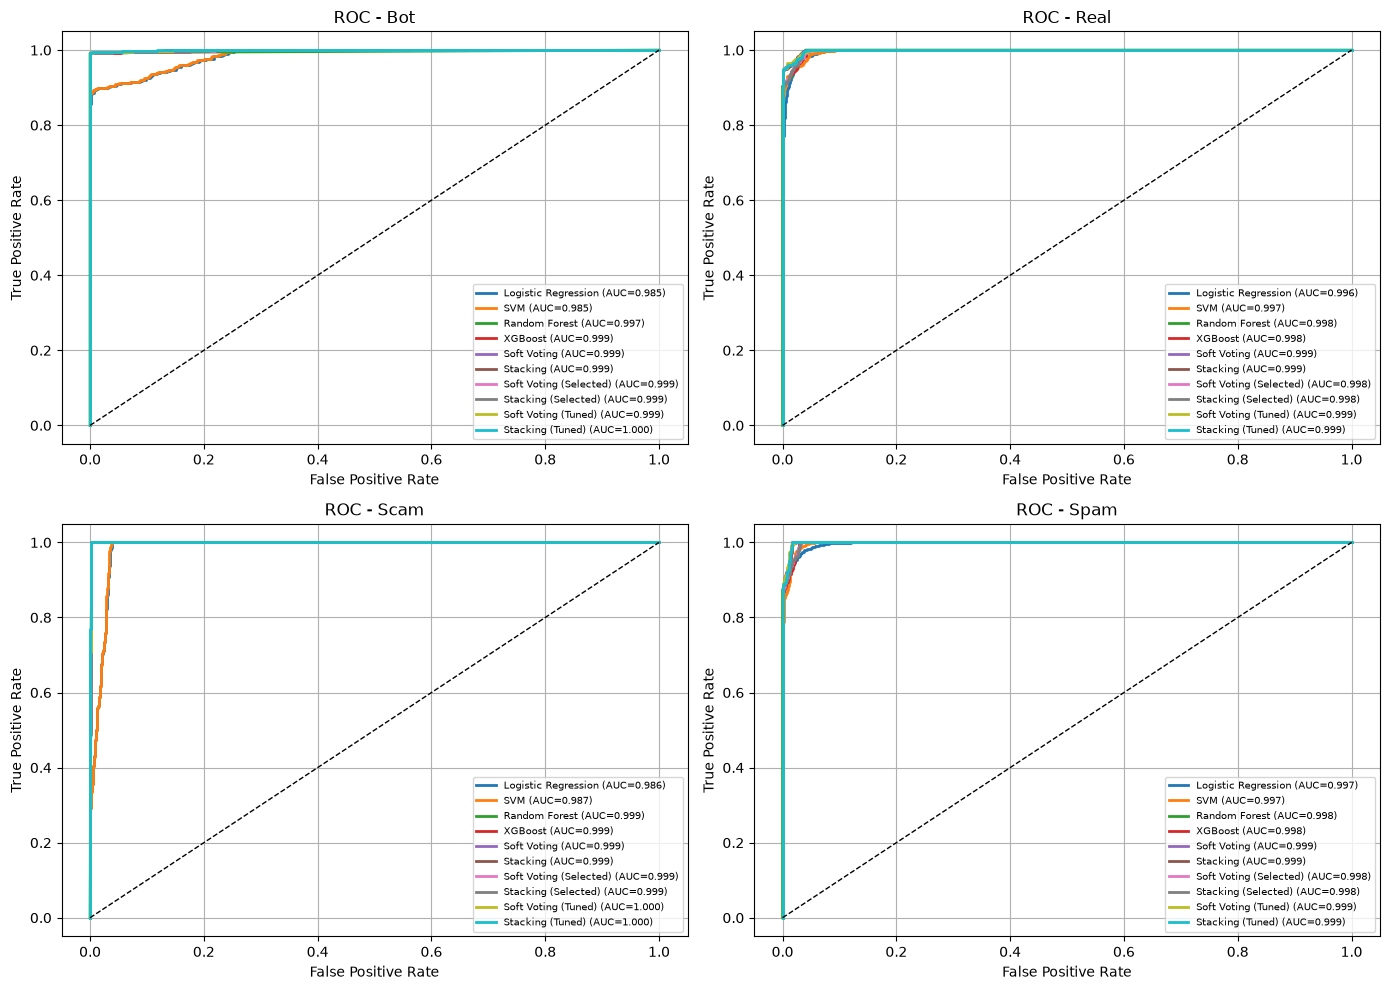

Macro one-vs-rest ROC-AUC:
Soft Voting (Tuned): 0.9992
Stacking (Tuned): 0.9992
Soft Voting: 0.9990
Stacking: 0.9990
XGBoost: 0.9985
Stacking (Selected): 0.9985
Soft Voting (Selected): 0.9985
Random Forest: 0.9977
SVM: 0.9916
Logistic Regression: 0.9912


In [18]:
# ROC curves are drawn for models that provide class probabilities.
prob_models = {
    name: result for name, result in all_results.items()
    if hasattr(result['model'], 'predict_proba')
}

probabilities = {
    name: result['model'].predict_proba(result['X_test'])
    for name, result in prob_models.items()
}

n_classes = len(class_names)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for class_index, ax in enumerate(axes[:n_classes]):
    for name, proba in probabilities.items():
        fpr, tpr, _ = roc_curve(
            y_test,
            proba[:, class_index],
            pos_label=class_index
        )
        ax.plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc(fpr, tpr):.3f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_title(f'ROC - {class_names[class_index]}')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(True)

for ax in axes[n_classes:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

y_test_one_hot = pd.get_dummies(y_test).values
auc_scores = {
    name: roc_auc_score(y_test_one_hot, proba, multi_class='ovr')
    for name, proba in probabilities.items()
}

print('Macro one-vs-rest ROC-AUC:')
for name, score in sorted(auc_scores.items(), key=lambda item: item[1], reverse=True):
    print(f'{name}: {score:.4f}')


In [19]:
# Do not choose a model from the test set. Use CV on training data for model selection,
# then use the untouched test set as the final check.
best_name = summary_df.iloc[0]['model']
best_result = all_results[best_name]

print('=' * 60)
print('FINAL SUMMARY')
print('=' * 60)
print('Original dataset:', df.shape)
print('After outlier removal:', df_clean.shape)
print('Number of features:', X.shape[1])
print('Classes:', list(class_names))
print('Selected features:', selected_features)
print()
print('Model selected by training CV:', best_name)
print(f"Training CV accuracy: {best_result['cv_mean']:.4f}")
print(f"Held-out test accuracy: {best_result['test_accuracy']:.4f}")
print('Feature set:', best_result['features'])

print('\nImportant interview point:')
print('The test set was not used to pick the best model.')


FINAL SUMMARY
Original dataset: (15000, 11)
After outlier removal: (13832, 12)
Number of features: 10
Classes: ['Bot', 'Real', 'Scam', 'Spam']
Selected features: ['Followers', 'Following', 'Posts', 'Mutual Friends', 'Threads']

Model selected by training CV: Stacking (Tuned)
Training CV accuracy: 0.9819
Held-out test accuracy: 0.9841
Feature set: full

Important interview point:
The test set was not used to pick the best model.


## 9. Unsupervised clustering

Uses the same cleaned feature matrix `X` (labels excluded), scaled and reduced with PCA.

In [20]:
# Clustering ignores the class labels. We only use the feature matrix X.
X_cluster = StandardScaler().fit_transform(X)

pca = PCA(n_components=0.95, random_state=SEED)
X_pca = pca.fit_transform(X_cluster)

print('Original dimensions:', X_cluster.shape[1])
print('Dimensions after PCA:', X_pca.shape[1])
print('Variance kept:', pca.explained_variance_ratio_.sum())


Original dimensions: 10
Dimensions after PCA: 9
Variance kept: 0.9646684832157704


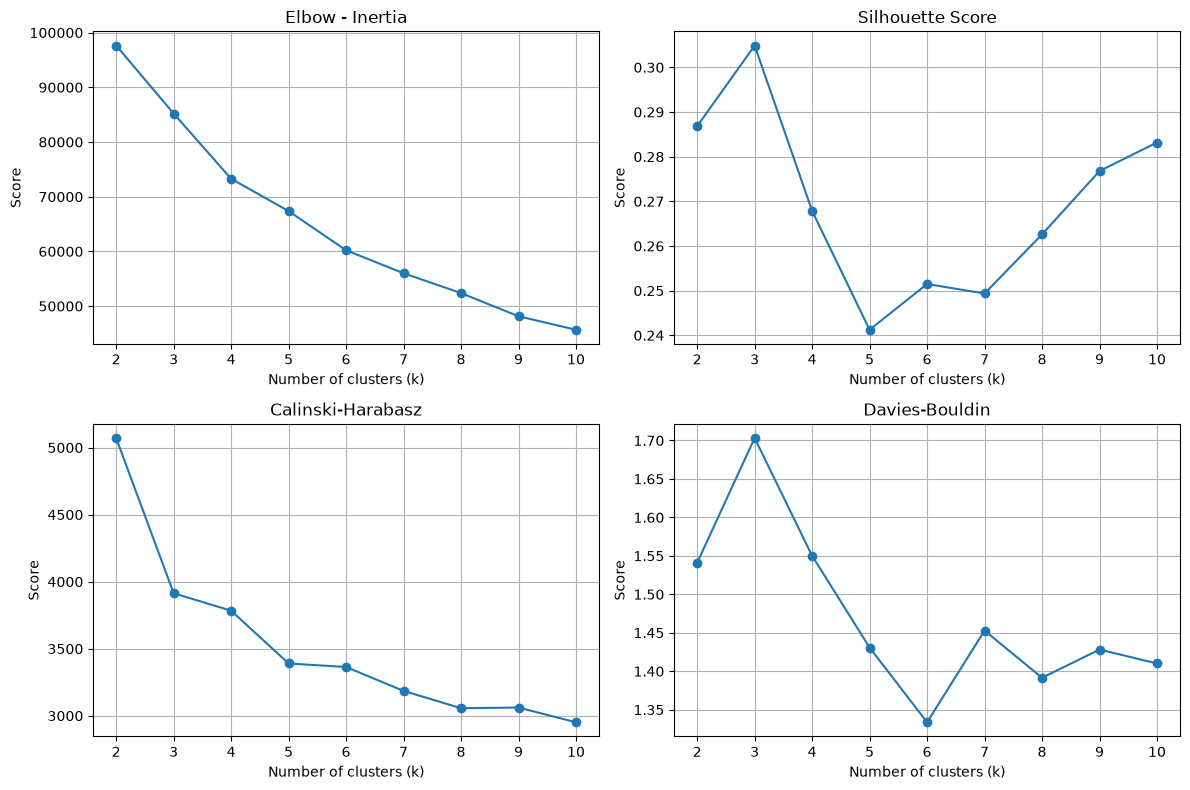

k=2: silhouette=0.2868, CH=5071.13, DB=1.5410
k=3: silhouette=0.3049, CH=3913.51, DB=1.7031
k=4: silhouette=0.2679, CH=3783.74, DB=1.5500
k=5: silhouette=0.2412, CH=3389.74, DB=1.4308
k=6: silhouette=0.2515, CH=3363.55, DB=1.3336
k=7: silhouette=0.2494, CH=3185.35, DB=1.4528
k=8: silhouette=0.2626, CH=3056.16, DB=1.3916
k=9: silhouette=0.2768, CH=3061.13, DB=1.4282
k=10: silhouette=0.2832, CH=2951.23, DB=1.4101


In [21]:
k_values = range(2, 11)
inertia = []
silhouette = []
calinski = []
davies = []

for k in k_values:
    model = KMeans(n_clusters=k, init='k-means++', random_state=SEED, n_init=10)
    cluster_labels = model.fit_predict(X_pca)

    inertia.append(model.inertia_)
    silhouette.append(silhouette_score(X_pca, cluster_labels))
    calinski.append(calinski_harabasz_score(X_pca, cluster_labels))
    davies.append(davies_bouldin_score(X_pca, cluster_labels))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plots = [
    ('Elbow - Inertia', inertia),
    ('Silhouette Score', silhouette),
    ('Calinski-Harabasz', calinski),
    ('Davies-Bouldin', davies),
]

for ax, (title, values) in zip(axes.ravel(), plots):
    ax.plot(list(k_values), values, 'o-')
    ax.set_title(title)
    ax.set_xlabel('Number of clusters (k)')
    ax.set_ylabel('Score')
    ax.grid(True)

plt.tight_layout()
plt.show()

for k, s, ch, db in zip(k_values, silhouette, calinski, davies):
    print(f'k={k}: silhouette={s:.4f}, CH={ch:.2f}, DB={db:.4f}')


In [22]:
suggested_k = list(k_values)[int(np.argmax(silhouette))]
print('Silhouette suggests k =', suggested_k)

optimal_k = suggested_k

kmeans = KMeans(
    n_clusters=optimal_k,
    init='k-means++',
    random_state=SEED,
    n_init=10
)
labels_km = kmeans.fit_predict(X_pca)

agg = AgglomerativeClustering(n_clusters=optimal_k)
labels_agg = agg.fit_predict(X_pca)

print('KMeans silhouette:', silhouette_score(X_pca, labels_km))
print('Agglomerative silhouette:', silhouette_score(X_pca, labels_agg))

# ARI compares how similarly the two clustering algorithms partition the same rows.
print('ARI between KMeans and Agglomerative:', adjusted_rand_score(labels_km, labels_agg))

df_clusters = df_clean.copy()
df_clusters['Cluster'] = labels_km


Silhouette suggests k = 3
KMeans silhouette: 0.304883661130617
Agglomerative silhouette: 0.19580748367390857
ARI between KMeans and Agglomerative: 0.4194515674160533


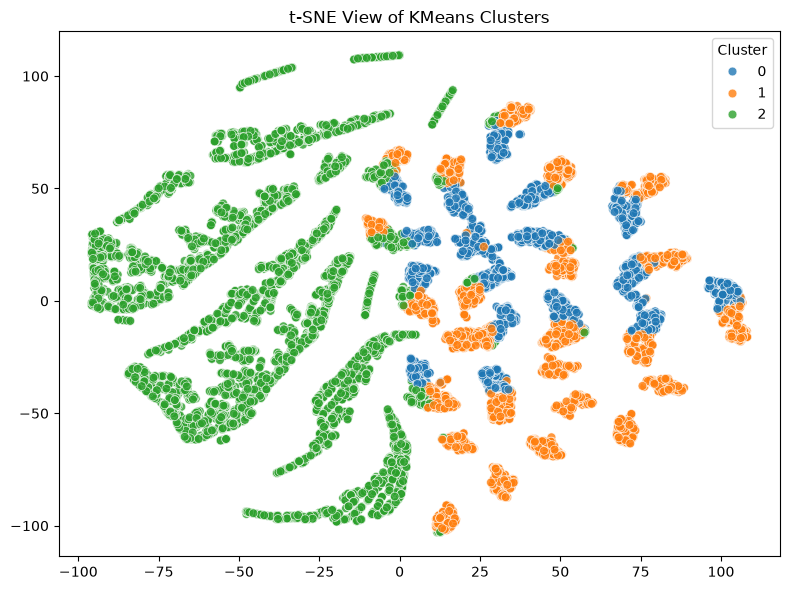

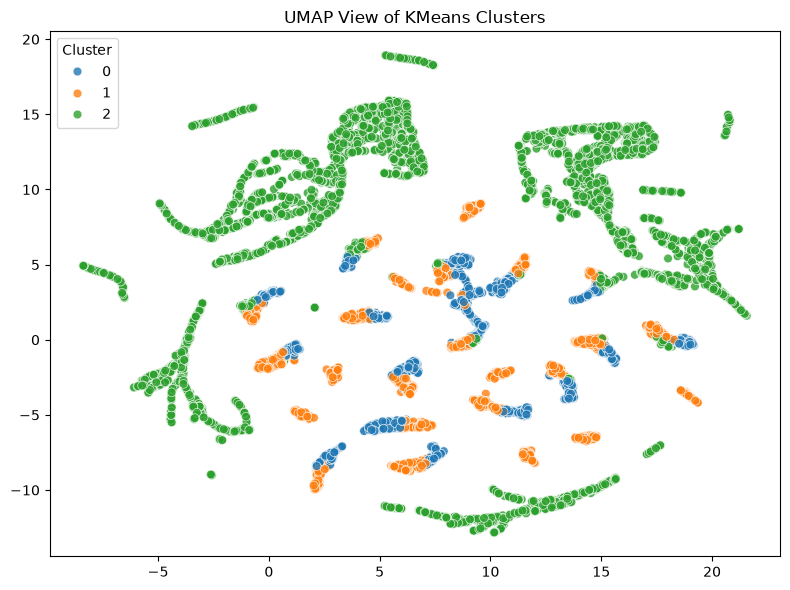

In [23]:
projections = {
    't-SNE': TSNE(n_components=2, random_state=SEED, perplexity=30),
    'UMAP': umap.UMAP(random_state=SEED),
}

for name, reducer in projections.items():
    embedding = reducer.fit_transform(X_pca)

    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        x=embedding[:, 0],
        y=embedding[:, 1],
        hue=df_clusters['Cluster'],
        palette='tab10',
        s=40,
        alpha=0.8
    )
    plt.title(f'{name} View of KMeans Clusters')
    plt.legend(title='Cluster')
    plt.tight_layout()
    plt.show()


In [24]:
def assess_cluster_strength(labels, X_data):
    labels = np.asarray(labels)
    counts = pd.Series(labels).value_counts()

    if len(counts) < 2:
        return {'strength': 'weak', 'reason': 'Only one cluster was found.'}

    sil = silhouette_score(X_data, labels)
    ch = calinski_harabasz_score(X_data, labels)
    db = davies_bouldin_score(X_data, labels)
    min_share = (counts / len(labels)).min()

    if sil >= 0.50:
        strength = 'strong'
    elif sil >= 0.25:
        strength = 'good'
    else:
        strength = 'weak'

    reasons = [
        f'Silhouette = {sil:.4f}',
        f'Calinski-Harabasz = {ch:.2f}',
        f'Davies-Bouldin = {db:.4f}',
        f'Smallest cluster share = {min_share:.3f}'
    ]

    return {
        'strength': strength,
        'n_clusters': len(counts),
        'cluster_counts': counts.to_dict(),
        'reasons': reasons
    }

cluster_result = assess_cluster_strength(labels_km, X_pca)

print('Cluster assessment:', cluster_result['strength'].upper())
for reason in cluster_result['reasons']:
    print('-', reason)

print('Remember: clustering quality scores are numerical evidence; domain knowledge is still needed to decide whether the clusters are meaningful.')


Cluster assessment: GOOD
- Silhouette = 0.3049
- Calinski-Harabasz = 3913.51
- Davies-Bouldin = 1.7031
- Smallest cluster share = 0.191
Remember: clustering quality scores are numerical evidence; domain knowledge is still needed to decide whether the clusters are meaningful.
